# Finalized Model Runs

This notebook contains the code used to train our finalized Vision Transformer model, as specified in our report (linked in readme). Key visualizations to analyze the model's outputs are also included.

In [2]:
#Importing packages
from torch.utils.data import DataLoader
import torch
import torch.optim as optim
import torch.nn as nn
import numpy as np
from tqdm import tqdm
import pandas as pd
from chromadb import PersistentClient as PersistentClient
from chromadb.errors import InternalError as CollectionError

#library functions
import src.dataloading as dataloading
import src.data_vis as data_vis
import src.model_functions as model_functions
import src.loss_functions as loss_functions
import src.models as models
from src.seeds import set_seed
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"

We set the seed for reproducibility, though results still vary slightly

In [3]:
g = set_seed()

## Data Loading

First, we load the data that was imported from LabelStudio. The data is split into training, validation, and testing splits, then batched into dataloaders.

In [4]:
labels_csv = r"camera_data/training_set_cameras_data.csv"

device = 'cuda'

model_path = 'weights/'
model_name = "final_model_testing.pth"

data = dataloading.get_data(labels_csv, 'camera_data/images/', replace_images = False, binarize=True, include_location=True)
train, val, test = dataloading.get_train_val_test(data = data, output_csvs=True)
train_dataloader, val_dataloader, test_dataloader = dataloading.get_train_val_test_dataloaders(train, val, test, generator = g)

100%|██████████| 6281/6281 [00:00<00:00, 7904.73it/s]


Instantiating the pre-trained model

In [7]:
encoder = models.create_encoder()
encoder.to(device);

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 5176.25it/s]
ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Instantiating the training settings

In [8]:
loss_func = loss_functions.TripletMarginLoss(margin = 0.19)
optimizer = optim.Adam(encoder.parameters(), lr=1e-5) 
num_epochs = 10

Training the model

In [ ]:
losses = model_functions.train_model(encoder, train_data=train_dataloader, 
                                num_epochs=num_epochs, loss_func=loss_func, 
                                optimizer=optimizer, name = model_name, 
                                path = 'weights/', device=device)

"losses = model_functions.train_model(encoder, train_data=train_dataloader, \n                                num_epochs=num_epochs, loss_func=loss_func, \n                                optimizer=optimizer, name = model_name, \n                                path = 'weights/', device=device)"

Saving the embeddings generated by this model

In [12]:
client = PersistentClient(path="embedding_data/") 

try:
    client.delete_collection(name="train_embeddings")
except Exception:
    pass

try:
    client.delete_collection(name="test_embeddings")
except Exception:
    pass


dataloading.save_full_embeddings(encoder, train_dataloader, 
                        "train_embeddings", persist_directory = "embedding_data/", 
                        device = device)


dataloading.save_full_embeddings(encoder, test_dataloader, 
                        "test_embeddings", persist_directory = "embedding_data/", 
                        device = device)
    
    
#Embeddings of training data, used to train the classification head
train_embeddings, train_labels, train_img_urls, train_a_ids, train_camera_locations = dataloading.load_full_embeddings(train, "train_embeddings", persist_directory = "embedding_data/")
train_embedding_dataloader = dataloading.embedding_to_dataloader(train_embeddings, train_labels, batch_size=32, generator = g)

#Embeddings of validation data, used to display results
test_embeddings, test_labels, test_img_urls, test_a_ids, test_camera_locations = dataloading.load_full_embeddings(test, "test_embeddings", persist_directory = "embedding_data/")

Visualizing the first two principal axes of the embedding space

In [13]:
reduced_embeddings, labels = model_functions.reduce_pca(train_embeddings, train_labels, dimensions=10)

Text(0.5, 1.0, 'First two axes of embedding space for final model')

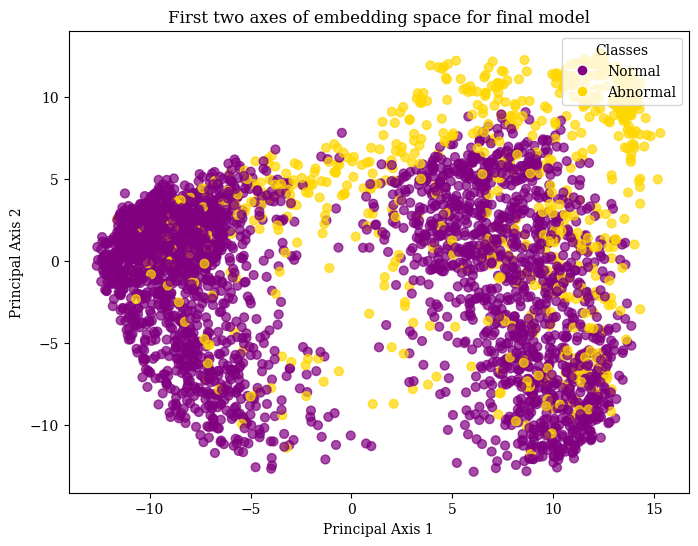

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
ax = data_vis.plot_data(reduced_embeddings, labels, pcx = 1, pcy = 2, ax=ax)
ax.set_title("First two axes of embedding space for final model")

Training classification head

In [15]:
losses = []

classification_head = models.ClassificationHead(num_classes=2)
classification_head.to(device)

head_criterion = nn.CrossEntropyLoss()
head_optimizer = optim.Adam(classification_head.parameters(), lr=1e-3) # Optimize only the new head

losses = model_functions.train_classification_head(classification_head, train_embedding_dataloader, num_epochs=10, criterion=head_criterion, optimizer=head_optimizer, 
                           device=device, model_name=model_name, model_path = "weights/", save=True)

#Report training and validation accuracy
classification_head.eval()

Processing batches in epoch 0:   0%|          | 0/118 [00:00<?, ?it/s]c:\Users\anees\Documents\Projects\alertcalifornia-anomaly-detection\.venv\Lib\site-packages\torch\utils\data\_utils\collate.py:288: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  return collate([torch.as_tensor(b) for b in batch], collate_fn_map=collate_fn_map)
Processing batches in epoch 9: 100%|██████████| 118/118 [00:01<00:00, 87.58it/s]


ClassificationHead(
  (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear(in_features=768, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)

Testing classification head outputs

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

def plot_confusion_matrix(true_labels, pred_labels, title):
    cm = confusion_matrix(true_labels, pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Abnormal"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

    recall = cm[1, 1] / (cm[1, 0] + cm[1, 1]) if (cm[1, 0] + cm[1, 1]) > 0 else 0
    precision = cm[1, 1] / (cm[0, 1] + cm[1, 1]) if (cm[0, 1] + cm[1, 1]) > 0 else 0
    print(f"Recall: {recall:.4f}")  
    print(f"Precision: {precision:.4f}")

def plot_roc_curve(true_labels, outputs, title):
    true_labels = true_labels.detach().cpu().numpy()
    positive_scores = torch.softmax(outputs.detach().cpu(), dim=-1)[:, 1].numpy()

    if len(np.unique(true_labels)) < 2:
        print("ROC AUC: undefined (only one class present)")
        return

    fpr, tpr, _ = roc_curve(true_labels, positive_scores)
    roc_auc = roc_auc_score(true_labels, positive_scores)

    plt.figure()
    plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()
    print(f"ROC AUC: {roc_auc:.4f}")

Overall training and testing accuracy

In [17]:
#Function to calculate accuracy of classification head on given embeddings and labels
def get_accuracy(outputs, labels):
    return (torch.argmax(outputs, dim = -1) == labels).float().mean().item()


train_embeddings_tensor = torch.Tensor(train_embeddings.to_numpy()).to(device)
test_embeddings_tensor = torch.Tensor(test_embeddings.to_numpy()).to(device)

train_labels_tensor = torch.Tensor(train_labels.to_numpy()).to(device)
test_labels_tensor = torch.Tensor(test_labels.to_numpy()).to(device)


train_outputs = classification_head(train_embeddings_tensor)
test_outputs = classification_head(test_embeddings_tensor)

print(f"Training accuracy: {get_accuracy(train_outputs, train_labels_tensor)}")
print(f"Test accuracy: {get_accuracy(test_outputs, test_labels_tensor)}")

Training accuracy: 0.9771762490272522
Test accuracy: 0.9427207708358765


Per-camera training and testing accuracy, along with precision, recall, and confusion matrices

In [18]:
train_camera_locations

0       Axis-MesaGrandeNorth
1           Axis-PalomarObs1
2        Axis-CoronadoHillsS
3           Axis-PalomarObs1
4       Axis-MesaGrandeNorth
                ...         
3763     Axis-CoronadoHillsS
3764     Axis-CoronadoHillsS
3765     Axis-CoronadoHillsS
3766    Axis-MesaGrandeNorth
3767        Axis-PalomarObs1
Name: location, Length: 3768, dtype: str

Camera location: Axis-MesaGrandeNorth
Training accuracy: 0.9929639101028442
Test accuracy: 0.9554455280303955


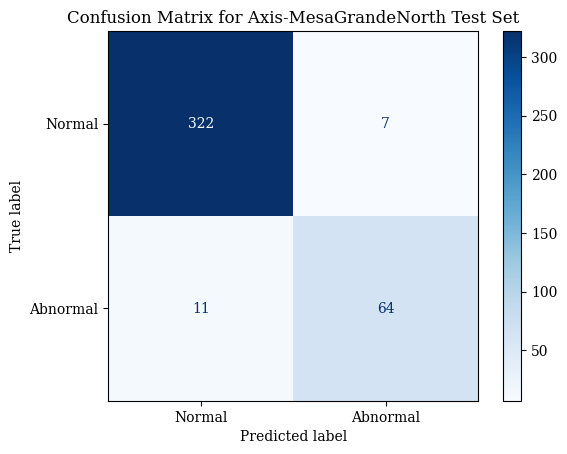

Recall: 0.8533
Precision: 0.9014


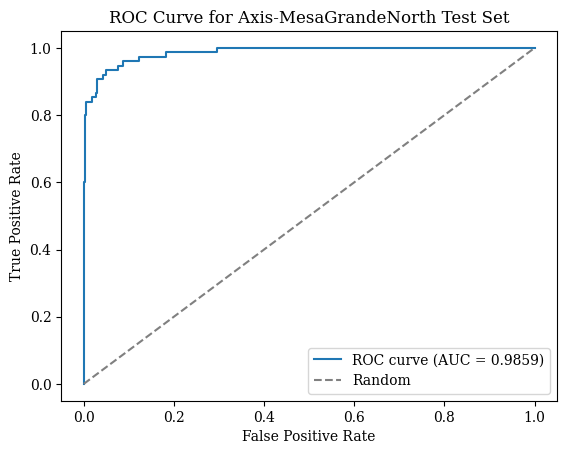

ROC AUC: 0.9859


Camera location: Axis-PalomarObs1
Training accuracy: 0.9751037359237671
Test accuracy: 0.9377990365028381


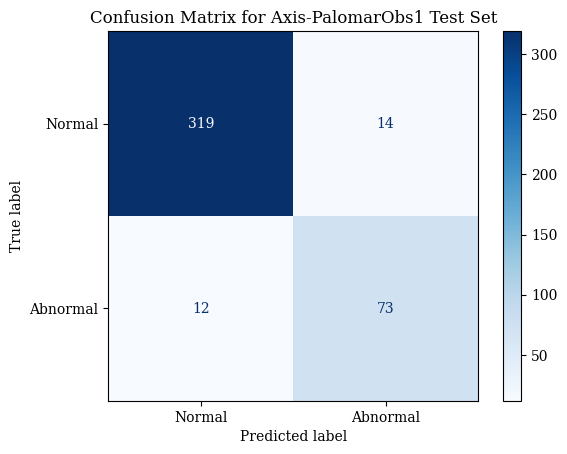

Recall: 0.8588
Precision: 0.8391


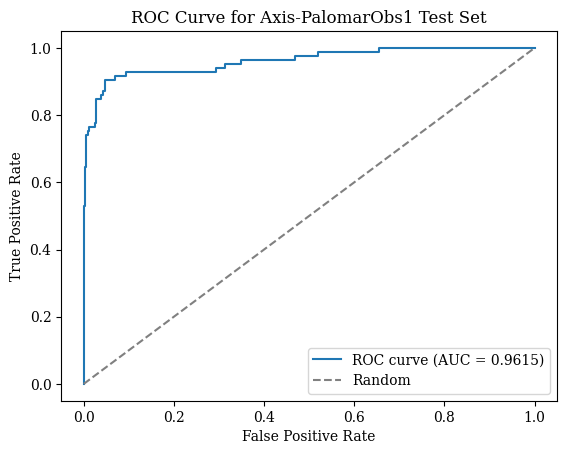

ROC AUC: 0.9615


Camera location: Axis-CoronadoHillsS
Training accuracy: 0.9663394093513489
Test accuracy: 0.9356321692466736


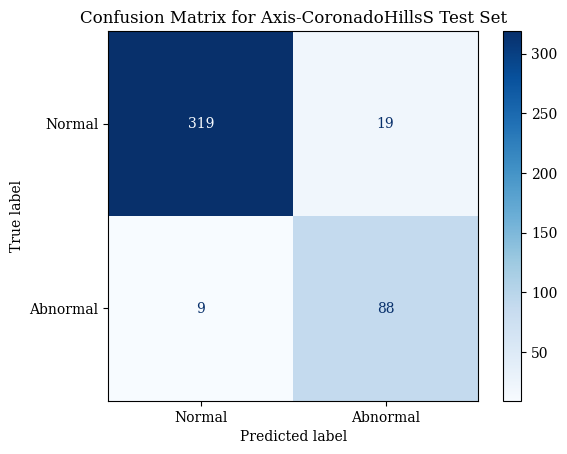

Recall: 0.9072
Precision: 0.8224


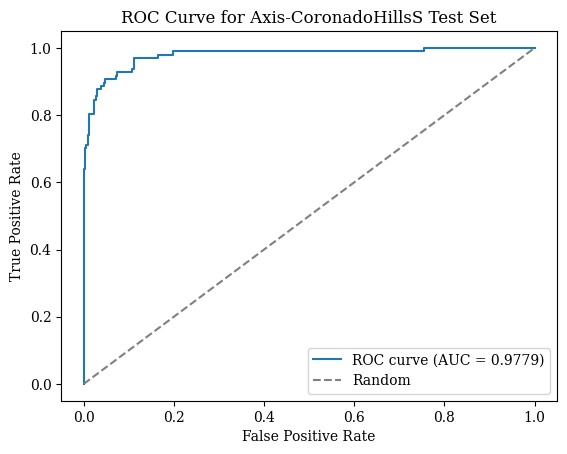

ROC AUC: 0.9779




In [19]:
for location in train_camera_locations.unique():
    train_idx = (train_camera_locations == location).to_numpy()
    test_idx = (test_camera_locations == location).to_numpy()

    location_train_outputs = classification_head(train_embeddings_tensor[train_idx])
    location_train_labels = train_labels_tensor[train_idx]

    location_test_outputs = classification_head(test_embeddings_tensor[test_idx])
    location_test_labels = test_labels_tensor[test_idx]

    location_train_acc = get_accuracy(location_train_outputs, location_train_labels)
    location_test_acc = get_accuracy(location_test_outputs, location_test_labels)
    
    print(f"Camera location: {location}")
    print(f"Training accuracy: {location_train_acc}")
    print(f"Test accuracy: {location_test_acc}")
    plot_confusion_matrix(location_test_labels.cpu(), torch.argmax(location_test_outputs, dim=-1).cpu(), title=f"Confusion Matrix for {location} Test Set")
    plot_roc_curve(location_test_labels, location_test_outputs, title=f"ROC Curve for {location} Test Set")
    print("\n")

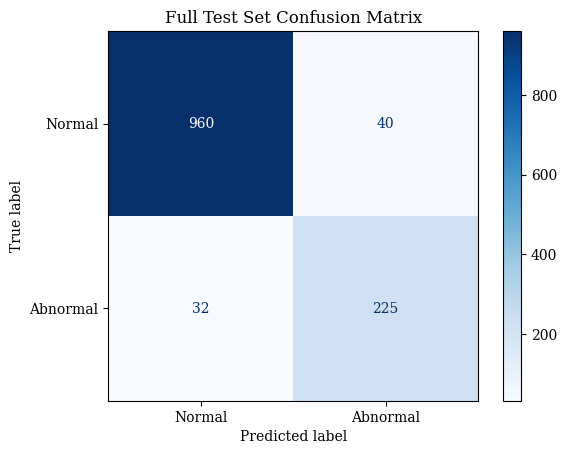

Recall: 0.8755
Precision: 0.8491


In [20]:
plot_confusion_matrix(test_labels_tensor.cpu(), torch.argmax(test_outputs, dim=-1).cpu(), title="Full Test Set Confusion Matrix")

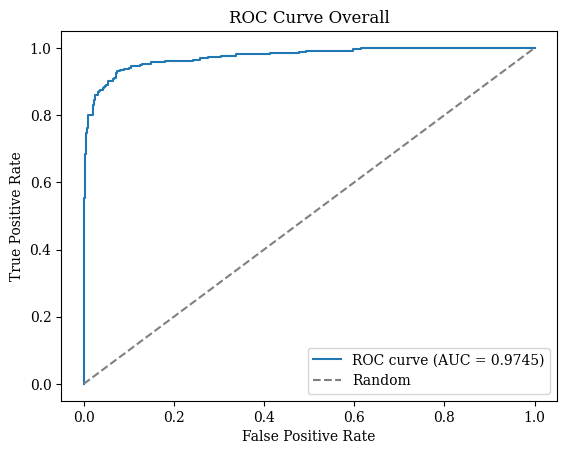

ROC AUC: 0.9745


In [21]:
plot_roc_curve(test_labels_tensor, test_outputs, title=f"ROC Curve Overall")